In [1]:
# Run this cell first — installs everything needed
!pip install xgboost shap mlflow scikit-learn pandas numpy matplotlib seaborn plotly joblib fastapi uvicorn streamlit pydantic -q
print("All packages installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/13

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import shap
import mlflow
import mlflow.sklearn
import joblib
import os, json

# Config
SEED       = 42
N_SPLITS   = 5
TEST_SIZE  = 0.2
np.random.seed(SEED)

print("All imports successful.")

All imports successful.


In [9]:
# --- CHANGE THESE PATHS TO YOUR FILES ---
TRAIN_PATH = '/content/train.csv'   # your training CSV
TEST_PATH  = '/content/test.csv'    # your test CSV (optional)
# ----------------------------------------

df = pd.read_csv(TRAIN_PATH)
print(df)
print(f"\nNull values:\n{df.isnull().sum()[df.isnull().sum()>0]}")

# Drop id column if present
if 'id' in df.columns:
    df = df.drop('id', axis=1)
print(df.info())
# Fix TotalCharges — sometimes stored as string with spaces
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean():.1%} ({df['Churn'].sum()} churned)")
print(f"\nNull values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
df.head(3)

            id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0            0    Male              0     Yes        Yes      29          Yes   
1            1    Male              0     Yes        Yes      58          Yes   
2            2    Male              0     Yes         No      58          Yes   
3            3  Female              0      No         No       1          Yes   
4            4  Female              0      No         No       1          Yes   
...        ...     ...            ...     ...        ...     ...          ...   
594189  594189    Male              0      No         No      57          Yes   
594190  594190  Female              0      No         No      72          Yes   
594191  594191  Female              0     Yes         No      72          Yes   
594192  594192  Female              0      No         No      32          Yes   
594193  594193  Female              1     Yes         No       2          Yes   

       MultipleLines Intern

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,0


In [10]:
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Churn by Contract', 'Churn by Internet Service',
        'Churn by Payment Method', 'Tenure vs Churn',
        'Monthly Charges vs Churn', 'Churn by Online Security'
    ]
)

# 1. Contract
ct = df.groupby('Contract')['Churn'].mean().reset_index()
fig.add_trace(go.Bar(x=ct['Contract'], y=ct['Churn'], marker_color=['#E24B4A','#EF9F27','#1D9E75'], name='Contract'), 1, 1)

# 2. Internet Service
it = df.groupby('InternetService')['Churn'].mean().reset_index()
fig.add_trace(go.Bar(x=it['InternetService'], y=it['Churn'], marker_color=['#378ADD','#7F77DD','#1D9E75'], name='Internet'), 1, 2)

# 3. Payment Method
pm = df.groupby('PaymentMethod')['Churn'].mean().reset_index()
fig.add_trace(go.Bar(x=pm['PaymentMethod'], y=pm['Churn'], marker_color='#E24B4A', name='Payment'), 1, 3)

# 4. Tenure distribution
fig.add_trace(go.Histogram(x=df[df['Churn']==1]['tenure'], name='Churned', marker_color='#E24B4A', opacity=0.7), 2, 1)
fig.add_trace(go.Histogram(x=df[df['Churn']==0]['tenure'], name='Stayed', marker_color='#1D9E75', opacity=0.7), 2, 1)

# 5. Monthly Charges
fig.add_trace(go.Histogram(x=df[df['Churn']==1]['MonthlyCharges'], name='Churned', marker_color='#E24B4A', opacity=0.7, showlegend=False), 2, 2)
fig.add_trace(go.Histogram(x=df[df['Churn']==0]['MonthlyCharges'], name='Stayed', marker_color='#1D9E75', opacity=0.7, showlegend=False), 2, 2)

# 6. Online Security
os_ct = df.groupby('OnlineSecurity')['Churn'].mean().reset_index()
fig.add_trace(go.Bar(x=os_ct['OnlineSecurity'], y=os_ct['Churn'], marker_color=['#E24B4A','#1D9E75','#EF9F27'], name='Security', showlegend=False), 2, 3)

fig.update_layout(height=600, title_text='EDA: Top Churn Drivers', barmode='overlay')
fig.show()

print("\nKey findings:")
print(f"  Month-to-month churn rate: {df[df['Contract']=='Month-to-month']['Churn'].mean():.1%}")
print(f"  Two-year contract churn rate: {df[df['Contract']=='Two year']['Churn'].mean():.1%}")
print(f"  Fiber optic churn rate: {df[df['InternetService']=='Fiber optic']['Churn'].mean():.1%}")
print(f"  Median tenure (churned): {df[df['Churn']==1]['tenure'].median():.0f} months")
print(f"  Median tenure (stayed):  {df[df['Churn']==0]['tenure'].median():.0f} months")


Key findings:
  Month-to-month churn rate: 42.1%
  Two-year contract churn rate: 1.0%
  Fiber optic churn rate: 41.5%
  Median tenure (churned): 10 months
  Median tenure (stayed):  46 months


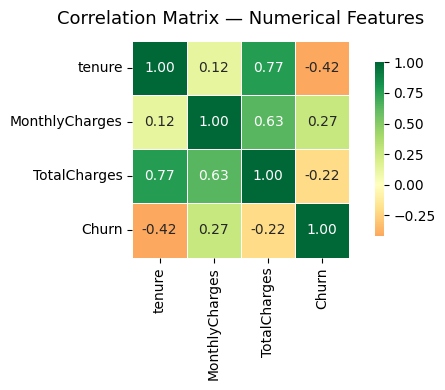


Correlation with Churn:
MonthlyCharges    0.272997
TotalCharges     -0.218365
tenure           -0.418453
Name: Churn, dtype: float64


In [11]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numerical Features', pad=12, fontsize=13)
plt.tight_layout()
plt.show()

print("\nCorrelation with Churn:")
print(corr['Churn'].drop('Churn').sort_values(ascending=False))

In [12]:
def engineer_features(df):
    """
    Creates 6 domain-driven features.
    Fitted only on training data — no leakage.
    """
    df = df.copy()

    # 1. Average spend per month (detects unusual billing)
    df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

    # 2. Tenure group — business-readable loyalty segments
    df['tenure_group'] = pd.cut(
        df['tenure'],
        bins=[0, 12, 24, 48, 73],
        labels=[0, 1, 2, 3],  # new / growing / established / loyal
        include_lowest=True
    ).astype(int)

    # 3. Number of add-on services (bundle depth)
    service_cols = ['OnlineSecurity', 'TechSupport', 'OnlineBackup',
                    'DeviceProtection', 'StreamingTV', 'StreamingMovies']
    df['service_count'] = df[service_cols].apply(
        lambda row: (row == 'Yes').sum(), axis=1
    )

    # 4. High-value established customer flag
    df['is_high_value'] = (
        (df['MonthlyCharges'] > 70) & (df['tenure'] > 24)
    ).astype(int)

    # 5. Cost per service (value perception)
    df['charge_per_service'] = df['MonthlyCharges'] / (df['service_count'] + 1)

    # 6. No-support risk flag (top EDA finding)
    df['no_support_risk'] = (
        (df['OnlineSecurity'] == 'No') & (df['TechSupport'] == 'No')
    ).astype(int)

    return df


df_fe = engineer_features(df)

new_features = ['avg_monthly_spend', 'tenure_group', 'service_count',
                'is_high_value', 'charge_per_service', 'no_support_risk']

print("New features created:")
print(df_fe[new_features].describe().round(2))

# Correlation of new features with churn
print("\nNew feature correlation with Churn:")
print(df_fe[new_features + ['Churn']].corr()['Churn'].drop('Churn').sort_values(ascending=False).round(3))

New features created:
       avg_monthly_spend  tenure_group  service_count  is_high_value  \
count          594194.00     594194.00      594194.00      594194.00   
mean               61.53          1.72           2.05           0.33   
std                36.75          1.22           1.97           0.47   
min                 0.72          0.00           0.00           0.00   
25%                25.47          0.00           0.00           0.00   
50%                64.98          2.00           2.00           0.00   
75%                86.95          3.00           4.00           1.00   
max              1046.91          3.00           6.00           1.00   

       charge_per_service  no_support_risk  
count           594194.00        594194.00  
mean                26.32             0.38  
std                 15.14             0.48  
min                  4.02             0.00  
25%                 18.23             0.00  
50%                 20.65             0.00  
75%           

In [13]:
X = df_fe.drop('Churn', axis=1)
y = df_fe['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,          # keeps churn ratio equal in both splits
    random_state=SEED
)

print(f"Train set: {X_train.shape[0]:,} rows | Churn rate: {y_train.mean():.1%}")
print(f"Val set:   {X_val.shape[0]:,} rows | Churn rate: {y_val.mean():.1%}")
print("\nChurn rate is consistent — stratification worked correctly.")

Train set: 475,355 rows | Churn rate: 22.5%
Val set:   118,839 rows | Churn rate: 22.5%

Churn rate is consistent — stratification worked correctly.


In [14]:
# Define column types
CATEGORICAL_COLS = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

NUMERICAL_COLS = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'avg_monthly_spend', 'tenure_group', 'service_count',
    'is_high_value', 'charge_per_service', 'no_support_risk'
]

# Only keep columns that exist in the dataset
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in X_train.columns]
NUMERICAL_COLS   = [c for c in NUMERICAL_COLS   if c in X_train.columns]

# Build sklearn ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_COLS)
    ],
    remainder='drop'
)

# Fit ONLY on training data
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)     # transform, NOT fit_transform

print(f"Processed feature matrix: {X_train_proc.shape}")
print(f"  Numerical features:     {len(NUMERICAL_COLS)}")
ohe_features = preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_COLS)
print(f"  After OHE (categorical): {len(ohe_features)} columns")
print(f"  Total features:          {X_train_proc.shape[1]}")

Processed feature matrix: (475355, 50)
  Numerical features:     9
  After OHE (categorical): 41 columns
  Total features:          50


In [15]:
mlflow.set_experiment("customer-churn-prediction")

xgb_params = {
    'n_estimators':      500,
    'learning_rate':     0.05,
    'max_depth':         4,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'min_child_weight':  5,
    'scale_pos_weight':  3,      # handles class imbalance (non-churn : churn ≈ 3:1)
    'objective':         'binary:logistic',
    'eval_metric':       'auc',
    'n_jobs':            -1,
    'random_state':      SEED,
    'early_stopping_rounds': 50,
}

with mlflow.start_run(run_name="xgboost-production-v1"):

    # Log hyperparameters
    mlflow.log_params({
        **xgb_params,
        'n_numerical_features':   len(NUMERICAL_COLS),
        'n_categorical_features': len(CATEGORICAL_COLS),
        'total_features':         X_train_proc.shape[1],
        'train_size':             len(X_train),
        'val_size':               len(X_val),
        'churn_rate_train':       round(float(y_train.mean()), 4),
    })

    # Train model
    model = XGBClassifier(**xgb_params)
    model.fit(
        X_train_proc, y_train,
        eval_set=[(X_val_proc, y_val)],
        verbose=100
    )

    # Predict
    val_probs = model.predict_proba(X_val_proc)[:, 1]
    val_preds = (val_probs >= 0.5).astype(int)

    # Compute metrics
    metrics = {
        'auc_roc':   round(roc_auc_score(y_val, val_probs), 4),
        'f1':        round(f1_score(y_val, val_preds), 4),
        'precision': round(precision_score(y_val, val_preds), 4),
        'recall':    round(recall_score(y_val, val_preds), 4),
    }

    # Log metrics
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(model, "churn_xgboost_model")

    print("=" * 45)
    print("  MODEL PERFORMANCE ON VALIDATION SET")
    print("=" * 45)
    for k, v in metrics.items():
        print(f"  {k:12s}: {v:.4f}")
    print("=" * 45)
    print(f"  Best iteration: {model.best_iteration}")
    print(f"\nRun tracked in MLflow. View with: mlflow ui")

2026/05/25 23:15:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/25 23:15:44 INFO mlflow.store.db.utils: Updating database tables
2026/05/25 23:15:50 INFO mlflow.tracking.fluent: Experiment with name 'customer-churn-prediction' does not exist. Creating a new experiment.


[0]	validation_0-auc:0.89293
[100]	validation_0-auc:0.91285
[200]	validation_0-auc:0.91435
[300]	validation_0-auc:0.91499
[400]	validation_0-auc:0.91530
[499]	validation_0-auc:0.91555


2026/05/25 23:16:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 23:16:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  MODEL PERFORMANCE ON VALIDATION SET
  auc_roc     : 0.9156
  f1          : 0.6900
  precision   : 0.5744
  recall      : 0.8639
  Best iteration: 497

Run tracked in MLflow. View with: mlflow ui


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.95      0.81      0.88     92076
     Churned       0.57      0.86      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.76      0.84      0.78    118839
weighted avg       0.87      0.83      0.84    118839



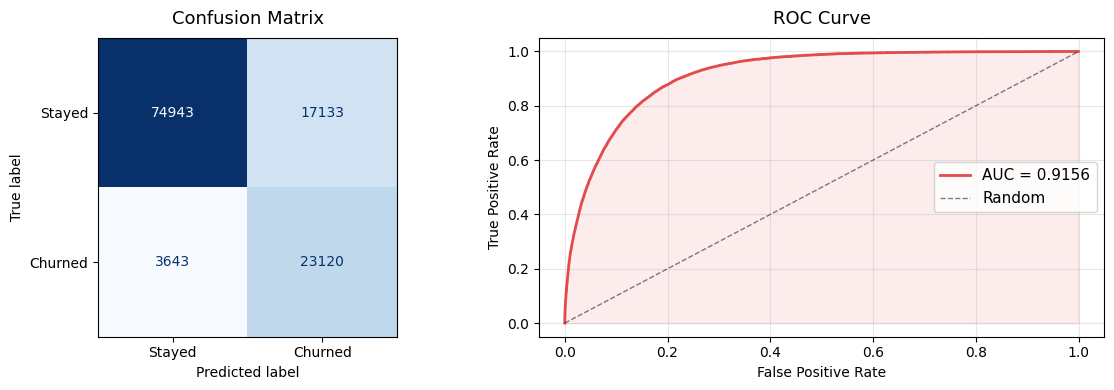

Saved: evaluation_charts.png


In [16]:
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_val, val_preds, target_names=['Stayed', 'Churned']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, pad=10)

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, val_probs)
auc = roc_auc_score(y_val, val_probs)
axes[1].plot(fpr, tpr, color='#E24B4A', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E24B4A')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, pad=10)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: evaluation_charts.png")

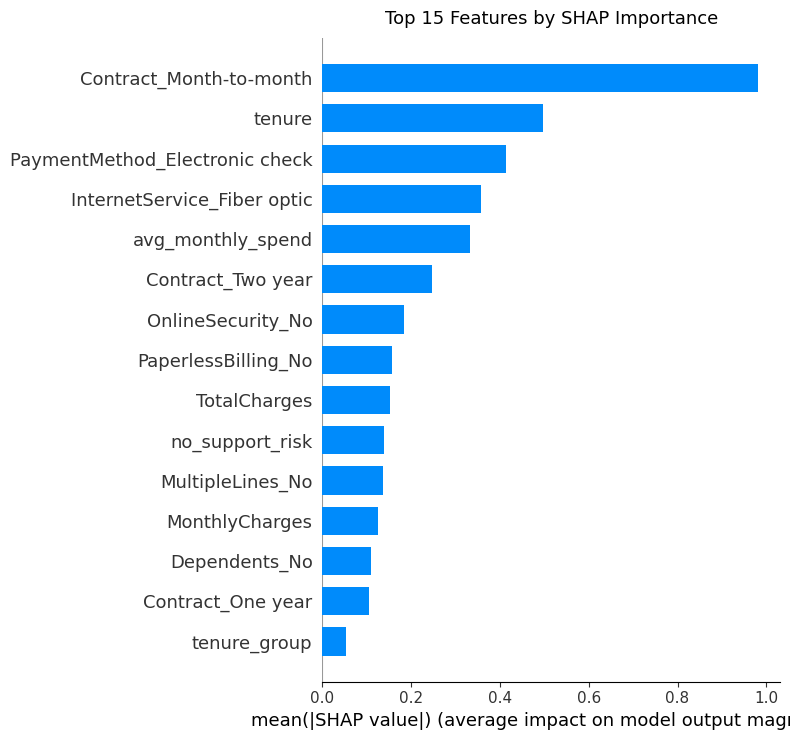

Saved: shap_importance.png


In [17]:
# Get feature names after preprocessing
num_feature_names = NUMERICAL_COLS
cat_feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_COLS))
all_feature_names = num_feature_names + cat_feature_names

# SHAP explainer
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_proc)

# Plot 1: Feature importance (bar)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_val_proc,
    feature_names=all_feature_names,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Top 15 Features by SHAP Importance', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_importance.png")

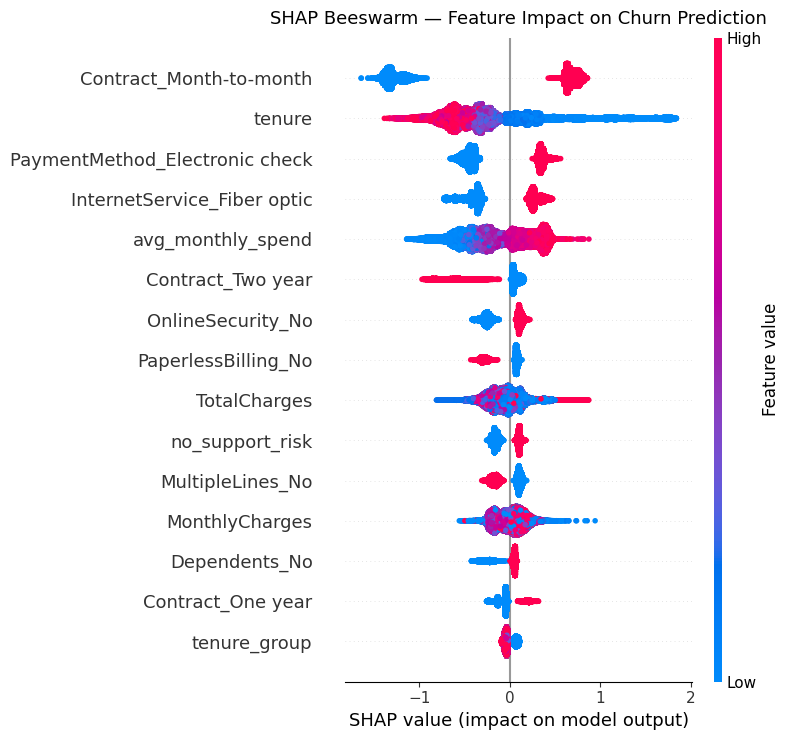

Saved: shap_beeswarm.png

How to read this chart:
  Red dots  = high feature value, pushing toward CHURN
  Blue dots = low feature value, pushing toward STAY
  X-axis    = how much this feature changed the prediction


In [18]:
# Plot 2: Beeswarm — shows direction of impact
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_val_proc,
    feature_names=all_feature_names,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact on Churn Prediction', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm.png")
print("\nHow to read this chart:")
print("  Red dots  = high feature value, pushing toward CHURN")
print("  Blue dots = low feature value, pushing toward STAY")
print("  X-axis    = how much this feature changed the prediction")

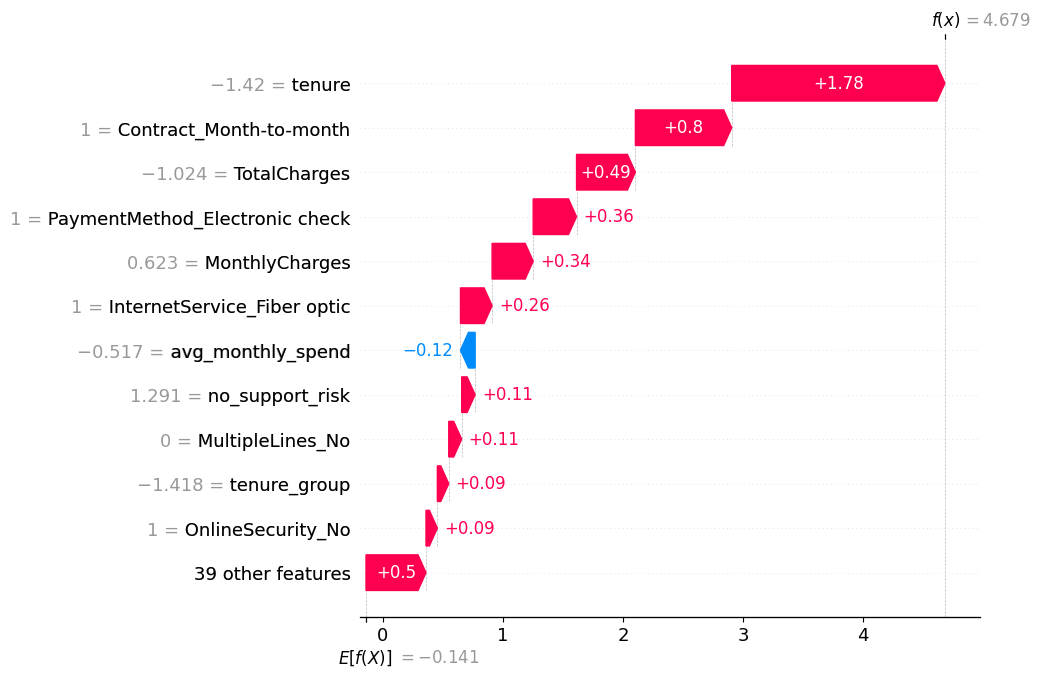

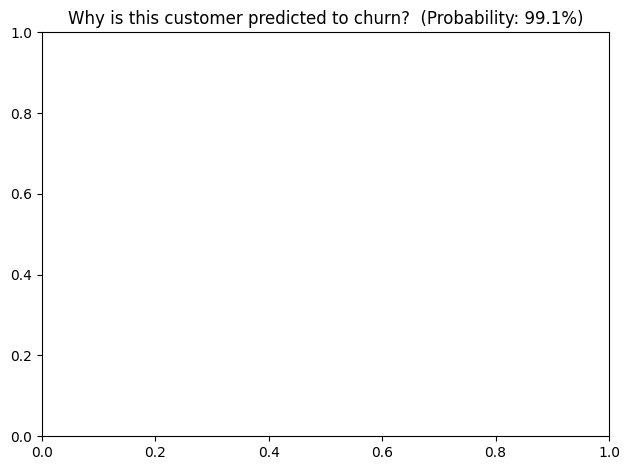

Saved: shap_single_customer.png

This plot shows EXACTLY why the model flagged this specific customer.
This is what you show in interviews when asked 'how do you explain your model?'


In [19]:
# Plot 3: Single customer explanation (waterfall plot)
# Pick a high-risk customer to explain
high_risk_idx = np.argmax(val_probs)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_val_proc[high_risk_idx],
        feature_names=all_feature_names
    ),
    max_display=12
)
plt.title(f"Why is this customer predicted to churn?  (Probability: {val_probs[high_risk_idx]:.1%})", fontsize=12)
plt.tight_layout()
plt.savefig('shap_single_customer.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_single_customer.png")
print("\nThis plot shows EXACTLY why the model flagged this specific customer.")
print("This is what you show in interviews when asked 'how do you explain your model?'")

In [20]:
from sklearn.pipeline import Pipeline as SKPipeline

# Build full pipeline for CV (preprocessor + model)
full_pipeline = SKPipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3,
        random_state=SEED,
        n_jobs=-1
    ))
])

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

cv_scores = cross_val_score(
    full_pipeline, X, y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"5-Fold Cross-Validation AUC-ROC:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  {'─'*30}")
print(f"  Mean:  {cv_scores.mean():.4f}")
print(f"  Std:   {cv_scores.std():.4f}  (lower = more stable)")
print()
if cv_scores.std() < 0.015:
    print("Model is stable — low variance across folds. Good for production.")
else:
    print("High variance across folds. Consider increasing training data or regularization.")

5-Fold Cross-Validation AUC-ROC:
  Fold 1: 0.9143
  Fold 2: 0.9153
  Fold 3: 0.9147
  Fold 4: 0.9157
  Fold 5: 0.9131
  ──────────────────────────────
  Mean:  0.9146
  Std:   0.0009  (lower = more stable)

Model is stable — low variance across folds. Good for production.


In [21]:
import os

os.makedirs('churn-api/model', exist_ok=True)

# Save model and preprocessor
joblib.dump(model,        'churn-api/model/xgb_model.pkl')
joblib.dump(preprocessor, 'churn-api/model/preprocessor.pkl')

# Save metadata (used by the API)
metadata = {
    "model_version":        "1.0.0",
    "model_type":           "XGBClassifier",
    "auc_roc":              round(float(metrics['auc_roc']), 4),
    "f1":                   round(float(metrics['f1']), 4),
    "precision":            round(float(metrics['precision']), 4),
    "recall":               round(float(metrics['recall']), 4),
    "categorical_cols":     CATEGORICAL_COLS,
    "numerical_cols":       NUMERICAL_COLS,
    "churn_threshold":      0.5,
    "training_rows":        len(X_train),
}

with open('churn-api/model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved artifacts:")
for f in os.listdir('churn-api/model'):
    size = os.path.getsize(f'churn-api/model/{f}')
    print(f"  churn-api/model/{f:30s}  {size:,} bytes")

print("\nNext step: create the FastAPI app and Dockerfile (see cells below).")

Saved artifacts:
  churn-api/model/xgb_model.pkl                   853,414 bytes
  churn-api/model/preprocessor.pkl                7,017 bytes
  churn-api/model/metadata.json                   739 bytes

Next step: create the FastAPI app and Dockerfile (see cells below).
